# Pairwise Spectral EMD Example

In [2]:
from pyspecter.SPECTER import SPECTER

# Utils
from particleloader import load
from particleloader.utils import center_and_normalize_zyphi
from rikabplotlib.plot_utils import newplot, plot_event


# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import time

# Load Dataset

In [23]:
# metric = spherical because these are full event cartesian 3 vectors
metric = "spherical"



# Cant run on all 50k events, since need N^2 memory. @Yoni, probbaly should make it so its a random subset of events here.
n_samples = 1000
batch_size = 10000



# Load datasets
dataset0 = np.load("/home/gambhirb/Documents/Physics/JetInterpretabilityDiffusion/qqbar_E2000_tgaus0_check_K9.npy")
dataset100 = np.load("/home/gambhirb/Documents/Physics/JetInterpretabilityDiffusion/qqbar_E2000_tgaus100_check_K9.npy")
dataset_training = np.load("/home/gambhirb/Documents/Physics/JetInterpretabilityDiffusion/training_data_small.npy")


# Need to convert to 4 vectors to use SPECTER in spherical mode.
def convert_3_to_4_vector(events):

    # Calculate the energy for each particle
    energies = np.linalg.norm(events, axis=2)  # Shape: (n_samples, n_particles)
    
    # Create a new array with an additional dimension for energy
    events_4d = np.zeros((events.shape[0], events.shape[1], 4))
    
    # Assign the original 3D vectors to the first three dimensions
    events_4d[:, :, 1:] = events
    
    # Assign the calculated energies to the 00th dimension
    events_4d[:, :, 0] = energies
    
    return events_4d

dataset0 = convert_3_to_4_vector(dataset0)
dataset100 = convert_3_to_4_vector(dataset100)
dataset_training = convert_3_to_4_vector(dataset_training)





# Set up SPECTER

In [13]:
# Set up and compile SPECTER
specter = SPECTER(compile = True)


Compiling SPECTER model...
Generating test events for tracing ...
Test events generated! Time taken:  30.265695333480835  seconds.
Compiling spectral representation functions ...
Compilation complete! Time taken:  104.07126569747925  seconds.


# Compute EMDs
Compute the EMDs between every pair of events, in parallel batches of `batch_size` events.

In [16]:
# Get list of pairwise indices
i_pairs, j_pairs = np.triu_indices(n_samples, k = 1)

# Pairwise EMDs between all pairs within a dataset
def compute_pairwise_emds(data, batch_size):

    # Initialize matrix to store pairwise EMDs
    pairwise_emds = np.zeros((n_samples, n_samples))

    # Compute batches
    start_time = time.time()
    for n in range(0, len(i_pairs), batch_size):

        print(f"Computing Batch {n}-{n+batch_size} of {len(i_pairs)} pairs. Elapsed Time: {time.time() - start_time :.3f} seconds")
        i_batch = i_pairs[n : n + batch_size]
        j_batch = j_pairs[n : n + batch_size]

        # Compute the pairwise EMDs
        emds = specter.spectralEMD(data[i_batch], data[j_batch], metric = metric)

        # Store the results
        pairwise_emds[i_batch, j_batch] = emds
        pairwise_emds[j_batch, i_batch] = emds

    print(f"Done! Total Elapsed Time: {time.time() - start_time :.3f} seconds")
    return pairwise_emds



In [22]:
# Compute for all datasets
dataset0_pairwise_emds = compute_pairwise_emds(dataset0, batch_size)
dataset100_pairwise_emds = compute_pairwise_emds(dataset100, batch_size)
training_pairwise_emds = compute_pairwise_emds(dataset_training, batch_size)

# Flatten the arrays
dataset0_emds_flat = dataset0_pairwise_emds[np.triu_indices(n_samples, k = 1)]
dataset100_emds_flat = dataset100_pairwise_emds[np.triu_indices(n_samples, k = 1)]
dataset_training_emds_flat = training_pairwise_emds[np.triu_indices(n_samples, k = 1)]


# Histogram of pairwise EMDs as a spectral function: rows of (omega, weight) sorted in omega
def histogram_to_spectral(values):

    counts, edges = np.histogram(values, bins = bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return np.stack([centers, counts / counts.sum()], axis = -1)

# Shared bins 
bins = np.linspace(0, max(dataset0_emds_flat.max(), dataset100_emds_flat.max(), dataset_training_emds_flat.max()), 101)



dataset0_spectral = histogram_to_spectral(dataset0_emds_flat)
dataset100_spectral = histogram_to_spectral(dataset100_emds_flat)
dataset_training_spectral = histogram_to_spectral(dataset_training_emds_flat)

training_to_0 = specter.ds2(dataset0_spectral[None], dataset_training_spectral[None])[0]
training_to_100 = specter.ds2(dataset100_spectral[None], dataset_training_spectral[None])[0]


# Final Answer
print(f"Distance between training and dataset 0: {training_to_0}")
print(f"Distance between training and dataset 100: {training_to_100}")



Computing Batch 0-10000 of 499500 pairs. Elapsed Time: 0.000 seconds
Computing Batch 10000-20000 of 499500 pairs. Elapsed Time: 0.035 seconds
Computing Batch 20000-30000 of 499500 pairs. Elapsed Time: 0.052 seconds
Computing Batch 30000-40000 of 499500 pairs. Elapsed Time: 0.067 seconds
Computing Batch 40000-50000 of 499500 pairs. Elapsed Time: 0.081 seconds
Computing Batch 50000-60000 of 499500 pairs. Elapsed Time: 0.096 seconds
Computing Batch 60000-70000 of 499500 pairs. Elapsed Time: 0.112 seconds
Computing Batch 70000-80000 of 499500 pairs. Elapsed Time: 0.127 seconds
Computing Batch 80000-90000 of 499500 pairs. Elapsed Time: 0.143 seconds
Computing Batch 90000-100000 of 499500 pairs. Elapsed Time: 0.158 seconds
Computing Batch 100000-110000 of 499500 pairs. Elapsed Time: 0.177 seconds
Computing Batch 110000-120000 of 499500 pairs. Elapsed Time: 0.194 seconds
Computing Batch 120000-130000 of 499500 pairs. Elapsed Time: 0.210 seconds
Computing Batch 130000-140000 of 499500 pairs. E

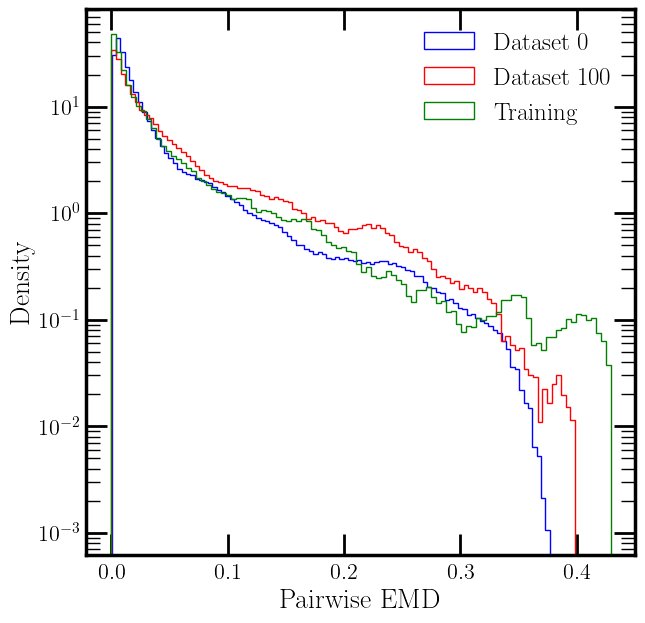

In [ ]:
# Histogram the results (upper triangle only)

fig, ax = newplot("full")
plt.hist(dataset0_emds_flat, bins = 100, density = True, color = "blue", histtype = "step", label = "Dataset 0")
plt.hist(dataset100_emds_flat, bins = 100, density = True, color = "red", histtype = "step", label = "Dataset 100")
plt.hist(dataset_training_emds_flat, bins = 100, density = True, color = "green", histtype = "step", label = "Training")
plt.yscale("log")
plt.xlabel("Pairwise EMD")
plt.ylabel("Density")
plt.legend()
